# Analyse bivariée: génération, genre, continent

Pour l'importation des données, voir ces carnets sparqlbook:
* [Occupations](../../sparqlbooks/wdt_import_occupations.sparqlbook.md)
* [Field](../../sparqlbooks/wdt_import_fields.sparqlbook.md)
* [Continents](../../sparqlbooks/wdt_import_citizenships.sparqlbook.md)


Pour vérifier l'ensemble des informations disponibles, voir ce carnet sparqlbook:
* [Information disponible](../../sparqlbooks/wdt_available_information.sparqlbook.md )



In [2]:
pip install scipy

  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/8b/c9/750d34788288d64ffbc94fdb4562f40f609d3f5ef27ab4f3a4ad00c9033e/scipy-1.16.0-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------ ------------------------- 20.5/60.8 kB 217.9 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/60.8 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 321.7 kB/s eta 0:00:00
   ---------------------------------------- 0.0/38.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.6 MB 1.9 MB/s eta 0:00:21
   ---------------------------------------- 0.1/38.6 MB 1.1 MB/s eta 0:00:36
   ---------------------------------------- 0.1/38.6 MB 930.9 kB/s eta 0:00:42
   ----------------------------------


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



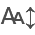

In [2]:
### Librairie à installer dans l'environnement conda (si on exécute en local)
# qui sera choisi pour exécuter le carnet
from SPARQLWrapper import SPARQLWrapper, JSON, TURTLE, XML, RDFXML
import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

### Module de visualisation de données
#  https://mwouts.github.io/itables/quick_start.html

from itables import init_notebook_mode, show

init_notebook_mode(all_interactive=False)




In [3]:
### Librairies déjà installées avec Python
import pprint
import csv
import sys

import sqlite3 as sql

import time
import datetime
from dateutil import parser

from importlib import reload
from shutil import copyfile


In [4]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')


import sparql_functions as spqf

## SPARQL Query qui récupère les données

On exécute la requête grâce à une fonction de la librairie locale qui réalise la mise en forme

In [5]:
## define SPARQL enpoint
endpoint = "https://ag13s8z3wvmae0kr.allegrograph.cloud/repositories/rappers"

In [6]:
query = """
PREFIX wd: <http://www.wikidata.org/entity/>
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>


SELECT  ?s (MAX(?label) as ?label) (xsd:integer(MAX(?birthDate)) as ?birthDate) 
            ( GROUP_CONCAT(DISTINCT ?genderLabel; separator=", ") AS ?genders ) 
            ( GROUP_CONCAT(DISTINCT ?countryLabel; separator=", ") AS ?countries )
            ( GROUP_CONCAT(DISTINCT ?continentLabel; separator=", ") AS ?continents )
            ( GROUP_CONCAT(DISTINCT ?occupationLabel; separator=", ") AS ?occupations )
            ( GROUP_CONCAT(DISTINCT ?fieldLabel; separator=", ") AS ?fields )
WHERE {
    GRAPH <https://github.com/Ziedellouzi/rappers/blob/main/graphs/wikidata-imported-data.md>
        {?s wdt:P21 ?gender;
            rdfs:label ?label;
            wdt:P569 ?birthDate;
            wdt:P27 ?country.
        ?gender rdfs:label ?genderLabel.
        ?country rdfs:label ?countryLabel.
        ?country wdt:P30 ?continent.
        ?continent rdfs:label ?continentLabel.
        OPTIONAL {  ?s wdt:P106 ?occupation.
                    ?occupation rdfs:label ?occupationLabel.}
        OPTIONAL {  ?s wdt:P106 ?field.
                    ?field rdfs:label ?fieldLabel.}

       
          }
}
GROUP BY ?s
"""

In [7]:
### Executer la requête avec les fonctions de la librairie locale
qr = spqf.get_json_sparql_result(endpoint,query)

In [8]:
r = [l for l in spqf.sparql_result_to_list(qr)]
print(len(r))
r[:3]

7829


[['http://www.wikidata.org/entity/Q89493281',
  'Jimmy Prime',
  '1993',
  'male',
  'Canada',
  'North America',
  'rapper, songwriter, singer',
  'rapper, songwriter, singer'],
 ['http://www.wikidata.org/entity/Q4993086',
  'Kreva',
  '1976',
  'male',
  'Japan',
  'Asia',
  'rapper, songwriter, record producer, singer',
  'rapper, songwriter, record producer, singer'],
 ['http://www.wikidata.org/entity/Q23664291',
  'Ko-Jo Cue',
  '1989',
  'male',
  'Ghana',
  'Africa',
  'rapper, songwriter, record producer, singer, composer',
  'rapper, songwriter, record producer, singer, composer']]

In [9]:
### Créer un DataFrame à partir du résultat
df_p = pd.DataFrame(r)
df_p.columns = ['personUri', 'personLabel', 'birthYear', 'gender', 'countries', 'continents', 'occupations', 'fields']
df_p.head()

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields
0,http://www.wikidata.org/entity/Q89493281,Jimmy Prime,1993,male,Canada,North America,"rapper, songwriter, singer","rapper, songwriter, singer"
1,http://www.wikidata.org/entity/Q4993086,Kreva,1976,male,Japan,Asia,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer"
2,http://www.wikidata.org/entity/Q23664291,Ko-Jo Cue,1989,male,Ghana,Africa,"rapper, songwriter, record producer, singer, c...","rapper, songwriter, record producer, singer, c..."
3,http://www.wikidata.org/entity/Q28498299,Tommy Cash,1991,male,Estonia,Europe,"rapper, singer","rapper, singer"
4,http://www.wikidata.org/entity/Q5026891,Camoflauge,1981,male,United States,North America,rapper,rapper


In [10]:
## transformer les années en entiers
df_p.birthYear = df_p.birthYear.apply(lambda x : int(x))

In [11]:
### Inspecter la structure du dataframe
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7829 entries, 0 to 7828
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   personUri    7829 non-null   object
 1   personLabel  7829 non-null   object
 2   birthYear    7829 non-null   int64 
 3   gender       7829 non-null   object
 4   countries    7829 non-null   object
 5   continents   7829 non-null   object
 6   occupations  7829 non-null   object
 7   fields       7829 non-null   object
dtypes: int64(1), object(7)
memory usage: 489.4+ KB


In [13]:
### Store to CSV
f_path = 'data/df_continent_occupations_fields_20250406.csv'
df_p.to_csv(f_path)

## Coder les continents et afficher leur distribution

In [14]:
### Inspecter les données
print(df_p.iloc[ :5 , :].continents)

0    North America
1             Asia
2           Africa
3           Europe
4    North America
Name: continents, dtype: object


In [15]:
### Regrouper et compter
df_contCode = df_p.groupby('continents').size()
df_contCode.columns=['effectif']
df_contCode = pd.DataFrame(df_contCode.sort_values( ascending = False))
#df_contCode.reset_index(inplace=True)
print(df_contCode.head(10))



                          0
continents                 
North America          3202
Europe                 2929
Asia                    772
Africa                  444
South America           190
Europe, Africa           63
Europe, Asia             41
Oceania                  31
Europe, North America    25
Africa, Europe           19


In [16]:
### Créer une fonction de codage
def codeContinents(continents):
    
    if 'Europe, Asia' in continents:
        output = 'Eurasia'    
    elif 'Europe' in continents:
        output = 'Europe'
    elif 'Africa' in continents:
        output = 'Africa'
    elif 'Oceania' in continents:
        output = 'Oceania'
    ## Issue with Russia, Russian Empire, Wikidata not consistent    
    elif 'Eurasia' in continents:
        output = 'Eurasia'
    elif 'North America' in continents:
        output = 'NorthAmerica'   
    elif 'Asia' in continents:
        output = 'Asia'
    elif 'South America' in continents:
        output = 'SouthAmerica' 
    else:
        output = 'Missing'                 
    return output    

In [17]:
### Tester la fonction
print(codeContinents('Oceania, North America, Africa'))

Africa


In [18]:
### On ajoute une nouvelle colonne 'contCode' et y on met pour chaque ligne le résultat de la fonction
df_p['contCode'] = df_p.apply(lambda x: codeContinents(x['continents']), axis=1)
df_p.head(3)

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode
0,http://www.wikidata.org/entity/Q89493281,Jimmy Prime,1993,male,Canada,North America,"rapper, songwriter, singer","rapper, songwriter, singer",NorthAmerica
1,http://www.wikidata.org/entity/Q4993086,Kreva,1976,male,Japan,Asia,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer",Asia
2,http://www.wikidata.org/entity/Q23664291,Ko-Jo Cue,1989,male,Ghana,Africa,"rapper, songwriter, record producer, singer, c...","rapper, songwriter, record producer, singer, c...",Africa


In [19]:


### Regrouper et compter
df_contCode = df_p.groupby('contCode').size()
df_contCode = pd.DataFrame(df_contCode.sort_values(ascending = True))
#df_contCode.reset_index(inplace=True)
df_contCode.columns=['effectif']
print(df_contCode)



              effectif
contCode              
Eurasia             41
Oceania             65
SouthAmerica       190
Africa             465
Asia               772
Europe            3061
NorthAmerica      3235


In [20]:
### How to handle data about Russians
df_p[df_p.countries.str.contains('Russi')].head(7)

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode
112,http://www.wikidata.org/entity/Q4261481,Lika MC,1972,female,"Russia, Soviet Union","Europe, Asia","manufacturer, rapper, record producer, singer,...","manufacturer, rapper, record producer, singer,...",Eurasia
120,http://www.wikidata.org/entity/Q104772431,Slame,1994,male,Russia,Europe,"rapper, singer","rapper, singer",Europe
364,http://www.wikidata.org/entity/Q4401088,Rustaveli,1978,male,Russia,Europe,"rapper, musician, singer, poet","rapper, musician, singer, poet",Europe
403,http://www.wikidata.org/entity/Q176846,Timati,1983,male,Russia,Europe,"rapper, songwriter, record producer, singer, e...","rapper, songwriter, record producer, singer, e...",Europe
411,http://www.wikidata.org/entity/Q116213729,Molodoj Platon,2004,male,Russia,Europe,"rapper, singer","rapper, singer",Europe
460,http://www.wikidata.org/entity/Q18395957,L'One,1985,male,Russia,Europe,"rapper, songwriter, singer","rapper, songwriter, singer",Europe
462,http://www.wikidata.org/entity/Q117317857,WHYLUV,1999,male,"Ukraine, Russia",Europe,"rapper, songwriter, musician, record producer,...","rapper, songwriter, musician, record producer,...",Europe


In [21]:
 
### Regrouper et compter les personnes issues de Russie
df_contCode = df_p[df_p.countries.str.contains('ussi')].groupby('contCode').size()
df_contCode = pd.DataFrame(df_contCode.sort_values(ascending = True))
#df_contCode.reset_index(inplace=True)
df_contCode.columns=['effectif']
print(df_contCode)



          effectif
contCode          
Eurasia         22
Europe         139


In [22]:
### On ajoute une nouvelle colonne et y on met pour chaque ligne le résultat de la fonction
df_p.iloc[ 97:101 , : ]

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode
97,http://www.wikidata.org/entity/Q909019,Dopeman,1974,male,Hungary,Europe,rapper,rapper,Europe
98,http://www.wikidata.org/entity/Q1395969,Frost,1964,male,United States,North America,"rapper, songwriter, musician, actor","rapper, songwriter, musician, actor",NorthAmerica
99,http://www.wikidata.org/entity/Q108908240,Lefty Sm,1992,male,Mexico,North America,rapper,rapper,NorthAmerica
100,http://www.wikidata.org/entity/Q16403661,Jaanus Saks,1986,male,Estonia,Europe,"rapper, singer","rapper, singer",Europe


In [23]:
# Noter la personne index 116, František Doutlík trouvé grâce à la propriété 'field'
df_p.iloc[ 111:118 :  ]

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode
111,http://www.wikidata.org/entity/Q6436503,Krazy,1976,male,United States,North America,rapper,rapper,NorthAmerica
112,http://www.wikidata.org/entity/Q4261481,Lika MC,1972,female,"Russia, Soviet Union","Europe, Asia","manufacturer, rapper, record producer, singer,...","manufacturer, rapper, record producer, singer,...",Eurasia
113,http://www.wikidata.org/entity/Q2584176,Shay Haley,1972,male,United States,North America,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer",NorthAmerica
114,http://www.wikidata.org/entity/Q3460670,Sabotage,1973,male,Brazil,South America,"rapper, songwriter, singer, actor","rapper, songwriter, singer, actor",SouthAmerica
115,http://www.wikidata.org/entity/Q16221472,Nickelz,1982,male,United States,North America,rapper,rapper,NorthAmerica
116,http://www.wikidata.org/entity/Q126927,Mase,1975,male,United States,North America,"rapper, songwriter","rapper, songwriter",NorthAmerica
117,http://www.wikidata.org/entity/Q104860456,S-Pion,1991,male,France,Europe,rapper,rapper,Europe


In [24]:
### Personnes trouvées grâce à leur champ, 'field'
# https://stackoverflow.com/questions/21055068/reversal-of-string-contains-in-python-pandas
dff = df_p[~(df_p.occupations.str.contains("astronomer|physicist"))]
print('Effectif: ', len(dff), '\n')
print(dff.head(2).personUri)
dff.head()

Effectif:  7829 

0    http://www.wikidata.org/entity/Q89493281
1     http://www.wikidata.org/entity/Q4993086
Name: personUri, dtype: object


,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode
0,http://www.wikidata.org/entity/Q89493281,Jimmy Prime,1993,male,Canada,North America,"rapper, songwriter, singer","rapper, songwriter, singer",NorthAmerica
1,http://www.wikidata.org/entity/Q4993086,Kreva,1976,male,Japan,Asia,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer",Asia
2,http://www.wikidata.org/entity/Q23664291,Ko-Jo Cue,1989,male,Ghana,Africa,"rapper, songwriter, record producer, singer, c...","rapper, songwriter, record producer, singer, c...",Africa
3,http://www.wikidata.org/entity/Q28498299,Tommy Cash,1991,male,Estonia,Europe,"rapper, singer","rapper, singer",Europe
4,http://www.wikidata.org/entity/Q5026891,Camoflauge,1981,male,United States,North America,rapper,rapper,NorthAmerica


### Distribution des continents: représentation graphique

In [25]:
### Regrouper et compter
df_contCode = df_p.groupby('contCode').size()
df_contCode = pd.DataFrame(df_contCode.sort_values(ascending = True))
#df_contCode.reset_index(inplace=True)
df_contCode.columns=['effectif']

df_contCode['frequence'] = (100 * df_contCode['effectif'] \
                                   / df_contCode['effectif'].sum()).round(2)
df_contCode



,effectif,frequence
contCode,,
Eurasia,41,0.52
Oceania,65,0.83
SouthAmerica,190,2.43
Africa,465,5.94
Asia,772,9.86
Europe,3061,39.10
NorthAmerica,3235,41.32


In [26]:

ljt = pd.DataFrame(df_contCode['frequence'].sort_values(ascending=False)).T
ljt



contCode,NorthAmerica,Europe,Asia,Africa,SouthAmerica,Oceania,Eurasia
frequence,41.32,39.1,9.86,5.94,2.43,0.83,0.52


In [27]:
### Définir les couleurs en fonction des continents
# Noter que cette liste des couleurs et continents
# doit être adaptée à l'ordre de tri des données 
# dans le graphique
col_palette = [
    "#DCDCDC",  # Gainsboro : Europe
    "#cd5c5c",  # Indian Red : NorthAmerica
    "#F4A261",  # Light Coral: Asia
    "#F6E58D",  # Light Yellow :SouthAmerica
    "#B2E0B2",  # Light Green : Oceania
    "#E3D4AD",  # Desert Sand : Eurasia
    "#A3C1DA",  # Light Blue : Africa    

]


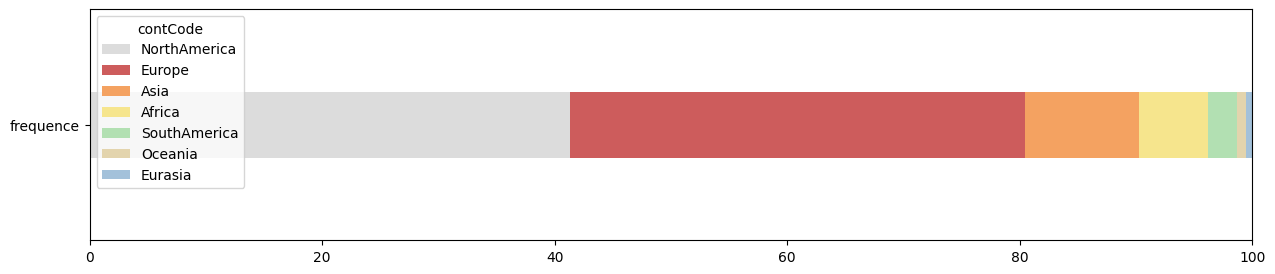

In [28]:


### Pandas plot reference
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html
## Barplots
# https://www.shanelynn.ie/bar-plots-in-python-using-pandas-dataframes/

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=col_palette, width=0.2, xlim=[0,100])

### Codage par période de vingt-cinq ans

In [84]:
### Créer une liste d'années pour séparer en périodes de 25 ans
# noter que la dernière année sera exclue, 
# elle donc doit être supérieure à la valeur maximale 
l_25 = list(range(1751, 2050, 25))
print(l_25[:5],l_25[-5:], len(l_25)-1)

[1751, 1776, 1801, 1826, 1851] [1926, 1951, 1976, 2001, 2026] 11


In [85]:
### Transformer les années de naissance en entiers
df_p.birthYear = df_p.birthYear.apply(lambda x : int(x))

In [86]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

df_p['per_25'] = pd.cut(df_p['birthYear'], l_25, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
df_p['per_25'] = df_p['per_25'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
df_p.head(3)

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode,per_25,genre_cont,code_discipline,disc_cont
0,http://www.wikidata.org/entity/Q89493281,Jimmy Prime,1993,male,Canada,North America,"rapper, songwriter, singer","rapper, songwriter, singer",NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other
1,http://www.wikidata.org/entity/Q4993086,Kreva,1976,male,Japan,Asia,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer",Asia,1976-2000,Asia_male,other,Asia_other
2,http://www.wikidata.org/entity/Q23664291,Ko-Jo Cue,1989,male,Ghana,Africa,"rapper, songwriter, record producer, singer, c...","rapper, songwriter, record producer, singer, c...",Africa,1976-2000,Africa_male,other,Africa_other


In [87]:
### distribution des naissances par périodes de 25 ans
naissances_per = df_p.groupby(by='per_25', observed=True).size()
print(naissances_per)

per_25
1876-1900       2
1901-1925     371
1926-1950      29
1951-1975    1182
1976-2000    5789
2001-2025     456
dtype: int64


### Comparer période et continent

In [88]:


### Tableau de contingence
X = "contCode"
Y = "per_25"  # "0"

ddf = df_p[[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
ddf



contCode,Africa,Asia,Eurasia,Europe,NorthAmerica,Oceania,SouthAmerica,Total
per_25,,,,,,,,
1876-1900,0,0,0,2,0,0,0,2
1901-1925,12,10,0,89,246,7,7,371
1926-1950,2,1,1,11,14,0,0,29
1951-1975,27,42,8,332,747,2,24,1182
1976-2000,401,636,31,2478,2058,50,135,5789
2001-2025,23,83,1,149,170,6,24,456
Total,465,772,41,3061,3235,65,190,7829


In [89]:
### Modifiy column order
print(ddf.columns.to_list())
ddf = ddf[['Europe', 'Eurasia',  'NorthAmerica', 'Asia', 'Africa', 'Oceania', 'SouthAmerica', 'Total']]
ddf

['Africa', 'Asia', 'Eurasia', 'Europe', 'NorthAmerica', 'Oceania', 'SouthAmerica', 'Total']


contCode,Europe,Eurasia,NorthAmerica,Asia,Africa,Oceania,SouthAmerica,Total
per_25,,,,,,,,
1876-1900,2,0,0,0,0,0,0,2
1901-1925,89,0,246,10,12,7,7,371
1926-1950,11,1,14,1,2,0,0,29
1951-1975,332,8,747,42,27,2,24,1182
1976-2000,2478,31,2058,636,401,50,135,5789
2001-2025,149,1,170,83,23,6,24,456
Total,3061,41,3235,772,465,65,190,7829


In [90]:
### Adapter à l'ordre des colonnes
col_palette_1 = [
    "#DCDCDC",  # Gainsboro : Europe
    "#E3D4AD",  # Desert Sand : Eurasia
    "#cd5c5c",  # Indian Red : NorthAmerica
    "#F4A261",  # Light Coral : Asia
    "#A3C1DA",  # Light Blue : Africa
    "#B2E0B2",  # Light Green : Oceania
    "#F6E58D",  # Light Yellow : SouthAmerica
    
]


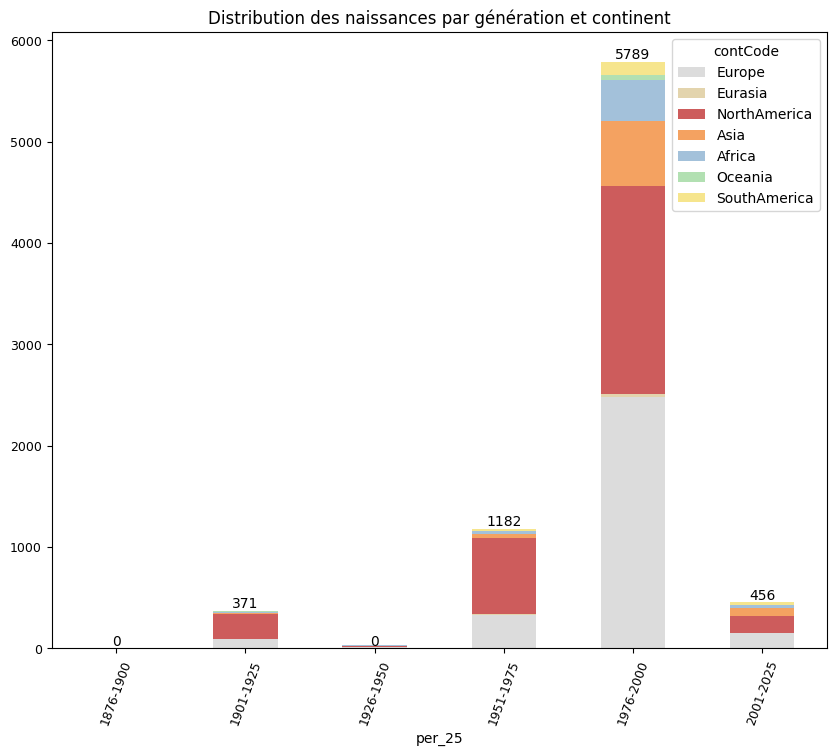

In [91]:
### Représenter l'évolution de la distribution dans le temps par continent
#  Documentation
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html

data = ddf.iloc[:-1,:-1]

ax = data.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8), 
                     color=col_palette_1)
plt.title('Distribution des naissances par génération et continent')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()

## Analyse bivariée: périodes, continents



On observe un fort déséquilibre entre les périodes et les continents. On peut présenter ce fait, par exemple en relevant le développement des États Unis et de la Russie (Eurasie) dès le milieu du 19e siècle. Mais on ne peut pas utiliser les données comme telles pour une analyse, il faudra restreindre l'analyse à la partie du tableau pour laquelle les effectis sont suffisants.



In [92]:
ddf

contCode,Europe,Eurasia,NorthAmerica,Asia,Africa,Oceania,SouthAmerica,Total
per_25,,,,,,,,
1876-1900,2,0,0,0,0,0,0,2
1901-1925,89,0,246,10,12,7,7,371
1926-1950,11,1,14,1,2,0,0,29
1951-1975,332,8,747,42,27,2,24,1182
1976-2000,2478,31,2058,636,401,50,135,5789
2001-2025,149,1,170,83,23,6,24,456
Total,3061,41,3235,772,465,65,190,7829


In [93]:
### Production du tableau à analyser
## Noter que pour que l'analyse soit significative en 
# termes de Chi-2 il faudrait partir de la ligne quatre
# Aussi, la dernière ligne est probablement incomplète
# en termes de génération
D = ddf.iloc[3:10,:-1].copy(deep=True)
D



contCode,Europe,Eurasia,NorthAmerica,Asia,Africa,Oceania,SouthAmerica
per_25,,,,,,,
1951-1975,332,8,747,42,27,2,24
1976-2000,2478,31,2058,636,401,50,135
2001-2025,149,1,170,83,23,6,24
Total,3061,41,3235,772,465,65,190


In [94]:
## Nombre de modalités ligne
K = D.shape[0]
## Nombre de modalités colonnes
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 4 , 7 ), effectif: 15256 , nombre max. facteurs: 3


In [95]:
### Valeurs produites par la fonction de la librairie 'stats'
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic.round(2), ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D, method='cramer')
print('Cramer: ', vc)

Chi2 : 393.81 , dof : 18
p-value : 1.7892710794614285e-72
phi2 = inertie (variance totale) : 0.02581314195180241
Cramer:  0.09275980083312384


In [96]:
### Situation à l'indépendance

indep = pd.DataFrame(expected)
indep.columns = D.columns
indep.index = D.index
indep.round(0).astype(int)

contCode,Europe,Eurasia,NorthAmerica,Asia,Africa,Oceania,SouthAmerica
per_25,,,,,,,
1951-1975,466,6,481,119,71,10,29
1976-2000,2284,31,2356,582,348,47,142
2001-2025,180,2,186,46,27,4,11
Total,3089,42,3187,787,470,63,191


In [97]:
D

contCode,Europe,Eurasia,NorthAmerica,Asia,Africa,Oceania,SouthAmerica
per_25,,,,,,,
1951-1975,332,8,747,42,27,2,24
1976-2000,2478,31,2058,636,401,50,135
2001-2025,149,1,170,83,23,6,24
Total,3061,41,3235,772,465,65,190


In [98]:


### Écart à l'indépendance:
# différence en effectifs entre le théorique et l'observé
#  Valeurs arrondies
### Doc. :
#   Bennani, p.30
#  https://openclassrooms.com/fr/courses/4525266-decrivez-et-nettoyez-votre-jeu-de-donnees/4775616-analysez-deux-variables-qualitatives-avec-le-chi-2
ecarts = (D-indep)
## Attention : arrondi aux entiers dans l'affichage
print(ecarts.round(0).astype(int))



contCode   Europe  Eurasia  NorthAmerica  Asia  Africa  Oceania  SouthAmerica
per_25                                                                       
1951-1975    -134        2           266   -77     -44       -8            -5
1976-2000     194        0          -298    54      53        3            -7
2001-2025     -31       -1           -16    37      -4        2            13
Total         -28       -1            48   -15      -5        2            -1


In [100]:


### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D-indep)/np.sqrt(indep),2))
residus_ponderes



contCode,Europe,Eurasia,NorthAmerica,Asia,Africa,Oceania,SouthAmerica
per_25,,,,,,,
1951-1975,-6.22,0.69,12.12,-7.04,-5.22,-2.44,-0.91
1976-2000,4.05,0.05,-6.15,2.25,2.87,0.49,-0.55
2001-2025,-2.31,-0.91,-1.15,5.49,-0.84,1.21,3.85
Total,-0.51,-0.09,0.85,-0.52,-0.23,0.24,-0.10


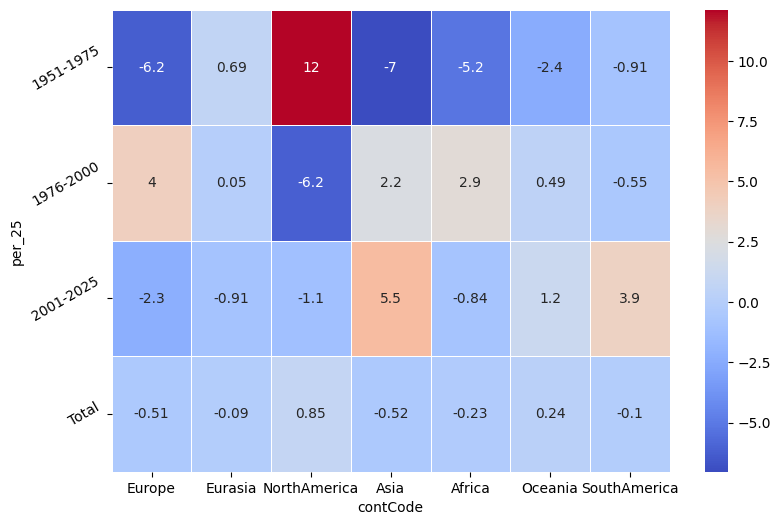

In [101]:
### Résidus pondérés
tableau = residus_ponderes

fig, ax = plt.subplots(figsize=(9,6))         
# Sample figsize in inches
g = sns.heatmap(tableau, annot=tableau, cmap="coolwarm", linewidths=.5, ax=ax)
labels = tableau.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()



### En excluant l'Europe ou choisissant les pays

In [102]:
print(D.columns.to_list())
D.iloc[ : , 1:]

['Europe', 'Eurasia', 'NorthAmerica', 'Asia', 'Africa', 'Oceania', 'SouthAmerica']


contCode,Eurasia,NorthAmerica,Asia,Africa,Oceania,SouthAmerica
per_25,,,,,,
1951-1975,8,747,42,27,2,24
1976-2000,31,2058,636,401,50,135
2001-2025,1,170,83,23,6,24
Total,41,3235,772,465,65,190


In [103]:
### Valeurs produites par la fonction de la librairie 'stats'
statistic, p, dof, expected = stats.chi2_contingency(D.iloc[ : , 1:])

print('Chi2 :', statistic.round(2), ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D.iloc[ : , 1:], method='cramer')
print('Cramer: ', vc)

Chi2 : 258.71 , dof : 15
p-value : 1.987587512191356e-46
phi2 = inertie (variance totale) : 0.016957974005571683
Cramer:  0.09662838769875508


In [104]:
D[['Europe', 'Asia', 'Eurasia', 'NorthAmerica', 'SouthAmerica']]

contCode,Europe,Asia,Eurasia,NorthAmerica,SouthAmerica
per_25,,,,,
1951-1975,332,42,8,747,24
1976-2000,2478,636,31,2058,135
2001-2025,149,83,1,170,24
Total,3061,772,41,3235,190


In [105]:
### Valeurs produites par la fonction de la librairie 'stats'
statistic, p, dof, expected = stats.chi2_contingency(D[['Europe', 'Eurasia']])

print('Chi2 :', statistic.round(2), ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D[['Europe', 'Eurasia']], method='cramer')
print('Cramer: ', vc)

Chi2 : 3.39 , dof : 3
p-value : 0.33506221514648377
phi2 = inertie (variance totale) : 0.00022232884346549075
Cramer:  0.023578584637009004


## Continent et genre

In [106]:
df_p.head()

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode,per_25,genre_cont,code_discipline,disc_cont
0,http://www.wikidata.org/entity/Q89493281,Jimmy Prime,1993,male,Canada,North America,"rapper, songwriter, singer","rapper, songwriter, singer",NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other
1,http://www.wikidata.org/entity/Q4993086,Kreva,1976,male,Japan,Asia,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer",Asia,1976-2000,Asia_male,other,Asia_other
2,http://www.wikidata.org/entity/Q23664291,Ko-Jo Cue,1989,male,Ghana,Africa,"rapper, songwriter, record producer, singer, c...","rapper, songwriter, record producer, singer, c...",Africa,1976-2000,Africa_male,other,Africa_other
3,http://www.wikidata.org/entity/Q28498299,Tommy Cash,1991,male,Estonia,Europe,"rapper, singer","rapper, singer",Europe,1976-2000,Europe_male,other,Europe_other
4,http://www.wikidata.org/entity/Q5026891,Camoflauge,1981,male,United States,North America,rapper,rapper,NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other


In [107]:


### Tableau de contingence
X = "contCode"
Y = "gender"  # "0"

ddgc = df_p[df_p.gender.isin(['female', 'male'])][[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
ddgc



contCode,Africa,Asia,Eurasia,Europe,NorthAmerica,Oceania,SouthAmerica,Total
gender,,,,,,,,
female,45,119,4,280,376,7,34,865
male,420,653,37,2774,2834,56,152,6926
Total,465,772,41,3054,3210,63,186,7791


### Créer la fonction

In [108]:
def bivariee_stats(D):
    ### Valeurs produites par la fonction de la librairie 'stats'
    statistic, p, dof, expected = stats.chi2_contingency(D)

    print('Chi2 :', statistic.round(2), ', dof :',dof)
    print('p-value :', p)


    print('phi2 = inertie (variance totale) :', statistic/n)


    ### Tableau à l'indépendance
    dfe = round(pd.DataFrame(expected),4)

    ### Coéfficient de Cramer
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

    vc = stats.contingency.association(D, method='cramer')
    print('Cramer: ', vc)

    ### Situation à l'indépendance
    indep = pd.DataFrame(expected)
    indep.columns = D.columns
    indep.index = D.index

    ### Résidus pondérés (avec le signe)
    ### Doc. :
    #   Rakotomalala, p.240
    residus_ponderes = (round((D-indep)/np.sqrt(indep),2))
    ### Résidus pondérés
    tableau = residus_ponderes

    fig, ax = plt.subplots(figsize=(9,3))         
    # Sample figsize in inches
    g = sns.heatmap(tableau, annot=tableau, cmap="coolwarm", linewidths=.5, ax=ax)
    xlabels = tableau.columns
    px = g.set_xticklabels(xlabels, rotation=60, size=8, 
                           ha='right', rotation_mode='anchor')
    ylabels = tableau.index
    py = g.set_yticklabels(ylabels, rotation=20, size=8)
    
    plt.show()

In [109]:
### Production du tableau à analyser
## Noter que pour que l'analyse soit significative en 
# termes de Chi-2 il faudrait partir de la ligne quatre
# Aussi, la dernière ligne est probablement incomplète
# en termes de génération
D = ddgc.iloc[:-1,:-1].copy(deep=True)
D



contCode,Africa,Asia,Eurasia,Europe,NorthAmerica,Oceania,SouthAmerica
gender,,,,,,,
female,45,119,4,280,376,7,34
male,420,653,37,2774,2834,56,152


Chi2 : 38.07 , dof : 6
p-value : 1.0873388516688267e-06
phi2 = inertie (variance totale) : 0.0024955688456669077
Cramer:  0.06990504433809824


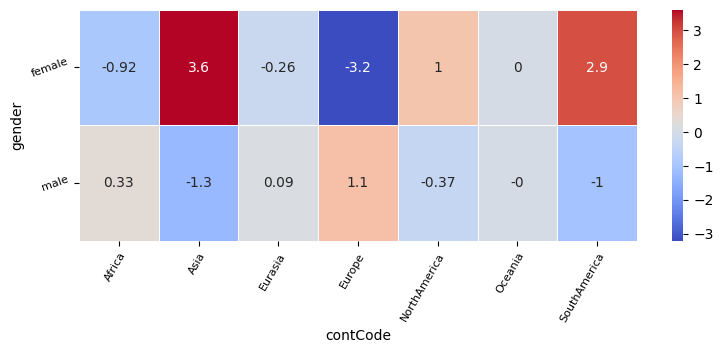

In [110]:
bivariee_stats(D)

### Genre et continent par époque

In [111]:
df_p['genre_cont'] = df_p.apply(lambda x: x.contCode + '_' + x.gender, axis=1)
df_p.head()

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode,per_25,genre_cont,code_discipline,disc_cont
0,http://www.wikidata.org/entity/Q89493281,Jimmy Prime,1993,male,Canada,North America,"rapper, songwriter, singer","rapper, songwriter, singer",NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other
1,http://www.wikidata.org/entity/Q4993086,Kreva,1976,male,Japan,Asia,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer",Asia,1976-2000,Asia_male,other,Asia_other
2,http://www.wikidata.org/entity/Q23664291,Ko-Jo Cue,1989,male,Ghana,Africa,"rapper, songwriter, record producer, singer, c...","rapper, songwriter, record producer, singer, c...",Africa,1976-2000,Africa_male,other,Africa_other
3,http://www.wikidata.org/entity/Q28498299,Tommy Cash,1991,male,Estonia,Europe,"rapper, singer","rapper, singer",Europe,1976-2000,Europe_male,other,Europe_other
4,http://www.wikidata.org/entity/Q5026891,Camoflauge,1981,male,United States,North America,rapper,rapper,NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other


In [112]:


### Tableau de contingence
X = "genre_cont"
Y = "per_25"  # "0"

ddgcp = df_p[df_p.gender.isin(['female', 'male'])][[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
ddgcp



genre_cont,Africa_female,Africa_male,Asia_female,Asia_male,Eurasia_female,Eurasia_male,Europe_female,Europe_male,NorthAmerica_female,NorthAmerica_male,Oceania_female,Oceania_male,SouthAmerica_female,SouthAmerica_male,Total
per_25,,,,,,,,,,,,,,,
1876-1900,0,0,0,0,0,0,0,2,0,0,0,0,0,0,2
1901-1925,3,9,2,8,0,0,8,81,31,212,1,6,1,6,368
1926-1950,1,1,1,0,0,1,2,9,3,11,0,0,0,0,29
1951-1975,0,27,2,40,1,7,22,310,68,679,0,2,0,24,1182
1976-2000,40,361,96,540,3,28,231,2240,249,1788,6,42,29,103,5756
2001-2025,1,22,18,65,0,1,17,132,25,144,0,6,4,19,454
Total,45,420,119,653,4,37,280,2774,376,2834,7,56,34,152,7791


In [113]:
### Limiter à la période significative, 20 siècle
D = ddgcp.iloc[6:-1,:-1].copy(deep=True)
D


genre_cont,Africa_female,Africa_male,Asia_female,Asia_male,Eurasia_female,Eurasia_male,Europe_female,Europe_male,NorthAmerica_female,NorthAmerica_male,Oceania_female,Oceania_male,SouthAmerica_female,SouthAmerica_male
per_25,,,,,,,,,,,,,,


#### Explorer les résultats et commenter

In [60]:
df_pef = df_p[df_p['genre_cont'] == 'Europe_female']
print(len(df_pef))

280


In [115]:
print(df_pef.groupby(by='countries', observed=True).size().sort_values(ascending=False).head(10))

countries
Germany                       40
United Kingdom                35
Spain                         26
France                        19
Italy                         13
Kingdom of the Netherlands    12
Poland                        11
Sweden                        11
Kingdom of Denmark            10
Finland                       10
dtype: int64


In [116]:
print(df_pef[df_pef.per_25 == '1976-2000'].groupby(by='countries', observed=True).size().sort_values(ascending=False).head(10))

countries
Germany                       31
United Kingdom                27
Spain                         24
France                        15
Sweden                        11
Kingdom of the Netherlands    11
Iceland                        9
Poland                         8
Italy                          8
Finland                        8
dtype: int64


In [117]:
fff = df_pef[(df_pef.per_25 == '1976-2000') & (df_pef.countries.str.contains('Germany'))]
print(len(fff))
fff.head()

36


,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode,per_25,genre_cont
206,http://www.wikidata.org/entity/Q15804914,Dee Ex,1982,female,Germany,Europe,rapper,rapper,Europe,1976-2000,Europe_female
695,http://www.wikidata.org/entity/Q1381968,Sookee,1983,female,"Germany, German Democratic Republic",Europe,rapper,rapper,Europe,1976-2000,Europe_female
1053,http://www.wikidata.org/entity/Q1421478,Nina Sonnenberg,1978,female,Germany,Europe,"radio personality, rapper, television presenter","radio personality, rapper, television presenter",Europe,1976-2000,Europe_female
1416,http://www.wikidata.org/entity/Q2257296,Schwesta Ewa,1984,female,"Germany, Poland",Europe,"rapper, singer","rapper, singer",Europe,1976-2000,Europe_female
1429,http://www.wikidata.org/entity/Q28057371,Haiyti,1993,female,Germany,Europe,"rapper, painter, singer","rapper, painter, singer",Europe,1976-2000,Europe_female


## Continent et discipline

In [118]:
df_p.head()

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode,per_25,genre_cont,code_discipline,disc_cont
0,http://www.wikidata.org/entity/Q89493281,Jimmy Prime,1993,male,Canada,North America,"rapper, songwriter, singer","rapper, songwriter, singer",NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other
1,http://www.wikidata.org/entity/Q4993086,Kreva,1976,male,Japan,Asia,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer",Asia,1976-2000,Asia_male,other,Asia_other
2,http://www.wikidata.org/entity/Q23664291,Ko-Jo Cue,1989,male,Ghana,Africa,"rapper, songwriter, record producer, singer, c...","rapper, songwriter, record producer, singer, c...",Africa,1976-2000,Africa_male,other,Africa_other
3,http://www.wikidata.org/entity/Q28498299,Tommy Cash,1991,male,Estonia,Europe,"rapper, singer","rapper, singer",Europe,1976-2000,Europe_male,other,Europe_other
4,http://www.wikidata.org/entity/Q5026891,Camoflauge,1981,male,United States,North America,rapper,rapper,NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other


In [119]:
def code_discipline(col1, col2):
    if  'astronomer' in col1\
        or 'astronomy' in col2:
        output = 'astronomy'
    elif 'physicist' in col1\
        or 'physics' in col2:
        output = 'physics'
    else:
        output = 'other'
    return output    


In [120]:
df_p['code_discipline'] = df_p.apply(lambda x: code_discipline(x.occupations, x.fields), axis=1)
df_p.head()

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode,per_25,genre_cont,code_discipline,disc_cont
0,http://www.wikidata.org/entity/Q89493281,Jimmy Prime,1993,male,Canada,North America,"rapper, songwriter, singer","rapper, songwriter, singer",NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other
1,http://www.wikidata.org/entity/Q4993086,Kreva,1976,male,Japan,Asia,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer",Asia,1976-2000,Asia_male,other,Asia_other
2,http://www.wikidata.org/entity/Q23664291,Ko-Jo Cue,1989,male,Ghana,Africa,"rapper, songwriter, record producer, singer, c...","rapper, songwriter, record producer, singer, c...",Africa,1976-2000,Africa_male,other,Africa_other
3,http://www.wikidata.org/entity/Q28498299,Tommy Cash,1991,male,Estonia,Europe,"rapper, singer","rapper, singer",Europe,1976-2000,Europe_male,other,Europe_other
4,http://www.wikidata.org/entity/Q5026891,Camoflauge,1981,male,United States,North America,rapper,rapper,NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other


In [121]:
df_p.groupby('code_discipline').size()

code_discipline
other    7829
dtype: int64

In [122]:


### Tableau de contingence
X = "contCode"
Y = "code_discipline"  # "0"

dddc = df_p[df_p.gender.isin(['female', 'male'])][[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
dddc



contCode,Africa,Asia,Eurasia,Europe,NorthAmerica,Oceania,SouthAmerica,Total
code_discipline,,,,,,,,
other,465,772,41,3054,3210,63,186,7791
Total,465,772,41,3054,3210,63,186,7791


In [124]:
### Profils des lignes
# axis=0 pour les colonnes

dddc_pl = dddc.apply(lambda x: (x/sum(x)*100*2).round(1), axis=1) 
dddc_pl

contCode,Africa,Asia,Eurasia,Europe,NorthAmerica,Oceania,SouthAmerica,Total
code_discipline,,,,,,,,
other,6.0,9.9,0.5,39.2,41.2,0.8,2.4,100.0
Total,6.0,9.9,0.5,39.2,41.2,0.8,2.4,100.0


In [125]:
### Adapter à l'ordre des colonnes
col_palette_2 = [
    "#A3C1DA",  # Light Blue : Africa
    "#F4A261",  # Light Coral : Asia
    "#E3D4AD",  # Desert Sand : Eurasia
    "#DCDCDC",  # Gainsboro : Europe
    "#cd5c5c",  # Indian Red : NorthAmerica
    "#B2E0B2",  # Light Green : Oceania
    "#F6E58D",  # Light Yellow : SouthAmerica
    
]


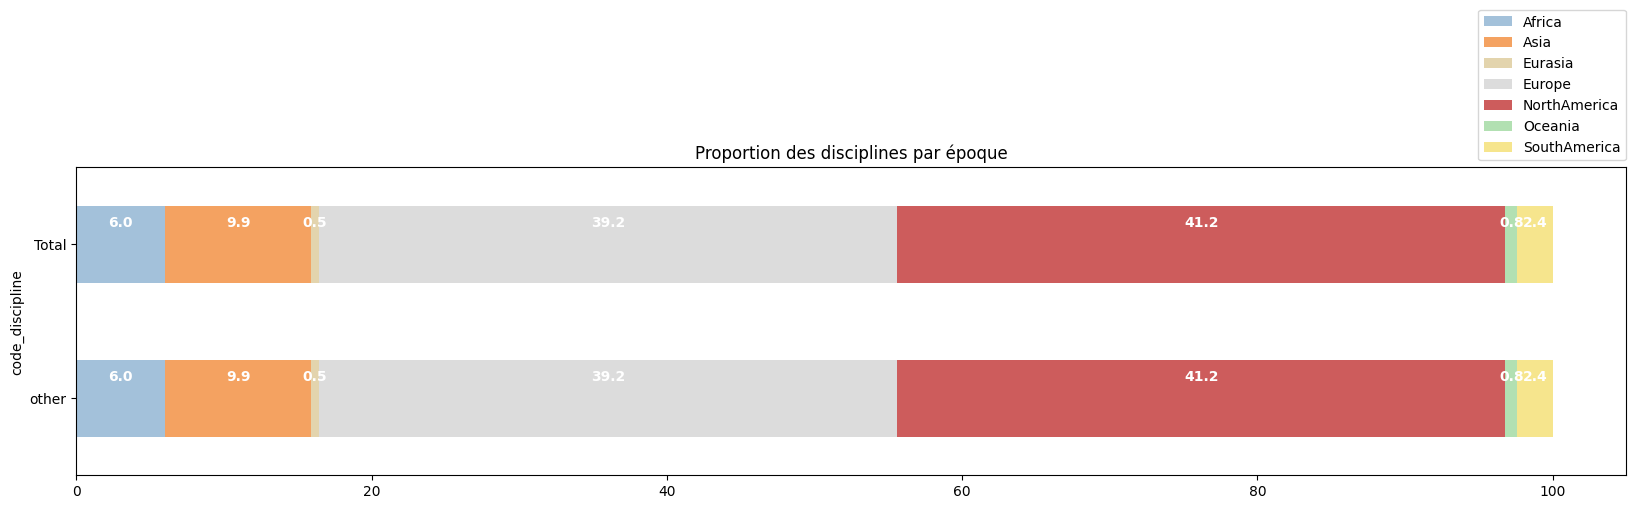

In [126]:


### https://www.shanelynn.ie/bar-plots-in-python-using-pandas-dataframes/

ax = dddc_pl.iloc[:, :-1].sort_index(ascending=False).plot(kind="barh",
                    stacked=True, figsize=(20,4), title='Proportion des disciplines par époque',
                    color=col_palette_2
                    )

### https://stackoverflow.com/questions/25447700/annotate-bars-with-values-on-pandas-bar-plots

for p in ax.patches:
    b = p.get_bbox()
    y_value=b.y1-b.y0
    ax.annotate(format(p.get_width(), '.1f'), 
                   (p.get_x() + p.get_width()/2, p.get_y() + p.get_height()), 
                   ha = 'center', va = 'center', 
                   size=10,
                   # style = 'italic',
                   weight='bold',
                   color = 'white',
                   xytext = (0, -12), 
                   textcoords = 'offset points')

ax.legend(bbox_to_anchor=(0.9, 1))

plt.show()

In [127]:
### Production du tableau à analyser
## Noter que pour que l'analyse soit significative en 
# termes de Chi-2 il faudrait partir de la ligne quatre
# Aussi, la dernière ligne est probablement incomplète
# en termes de génération
D = dddc.iloc[:-1,:-1].copy(deep=True)
D



contCode,Africa,Asia,Eurasia,Europe,NorthAmerica,Oceania,SouthAmerica
code_discipline,,,,,,,
other,465,772,41,3054,3210,63,186


## Discipline et continent par époque

In [129]:
df_p.head(2)

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode,per_25,genre_cont,code_discipline,disc_cont
0,http://www.wikidata.org/entity/Q89493281,Jimmy Prime,1993,male,Canada,North America,"rapper, songwriter, singer","rapper, songwriter, singer",NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other
1,http://www.wikidata.org/entity/Q4993086,Kreva,1976,male,Japan,Asia,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer",Asia,1976-2000,Asia_male,other,Asia_other


In [130]:
df_p['disc_cont'] = df_p.apply(lambda x: x.contCode + '_' + x.code_discipline, axis=1)
df_p.head(2)

,personUri,personLabel,birthYear,gender,countries,continents,occupations,fields,contCode,per_25,genre_cont,code_discipline,disc_cont
0,http://www.wikidata.org/entity/Q89493281,Jimmy Prime,1993,male,Canada,North America,"rapper, songwriter, singer","rapper, songwriter, singer",NorthAmerica,1976-2000,NorthAmerica_male,other,NorthAmerica_other
1,http://www.wikidata.org/entity/Q4993086,Kreva,1976,male,Japan,Asia,"rapper, songwriter, record producer, singer","rapper, songwriter, record producer, singer",Asia,1976-2000,Asia_male,other,Asia_other


In [131]:
### Tableau de contingence
X = "disc_cont"
Y = "per_25"  # "0"

dddcp = df_p[df_p.gender.isin(['female', 'male'])][[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
dddcp

disc_cont,Africa_other,Asia_other,Eurasia_other,Europe_other,NorthAmerica_other,Oceania_other,SouthAmerica_other,Total
per_25,,,,,,,,
1876-1900,0,0,0,2,0,0,0,2
1901-1925,12,10,0,89,243,7,7,368
1926-1950,2,1,1,11,14,0,0,29
1951-1975,27,42,8,332,747,2,24,1182
1976-2000,401,636,31,2471,2037,48,132,5756
2001-2025,23,83,1,149,169,6,23,454
Total,465,772,41,3054,3210,63,186,7791


In [132]:
### Limiter à la période significative, 20 siècle
D = dddcp.iloc[5:-1,:-1].copy(deep=True)
D


disc_cont,Africa_other,Asia_other,Eurasia_other,Europe_other,NorthAmerica_other,Oceania_other,SouthAmerica_other
per_25,,,,,,,
2001-2025,23,83,1,149,169,6,23
